User Data:

   id                      name                      email
0   1             Leanne Graham          Sincere@april.biz
1   2              Ervin Howell          Shanna@melissa.tv
2   3          Clementine Bauch         Nathan@yesenia.net
3   4          Patricia Lebsack  Julianne.OConner@kory.org
4   5          Chelsey Dietrich   Lucio_Hettinger@annie.ca
5   6      Mrs. Dennis Schulist    Karley_Dach@jasper.info
6   7           Kurtis Weissnat     Telly.Hoeger@billy.biz
7   8  Nicholas Runolfsdottir V       Sherwood@rosamond.me
8   9           Glenna Reichert    Chaim_McDermott@dana.io
9  10        Clementina DuBuque     Rey.Padberg@karina.biz


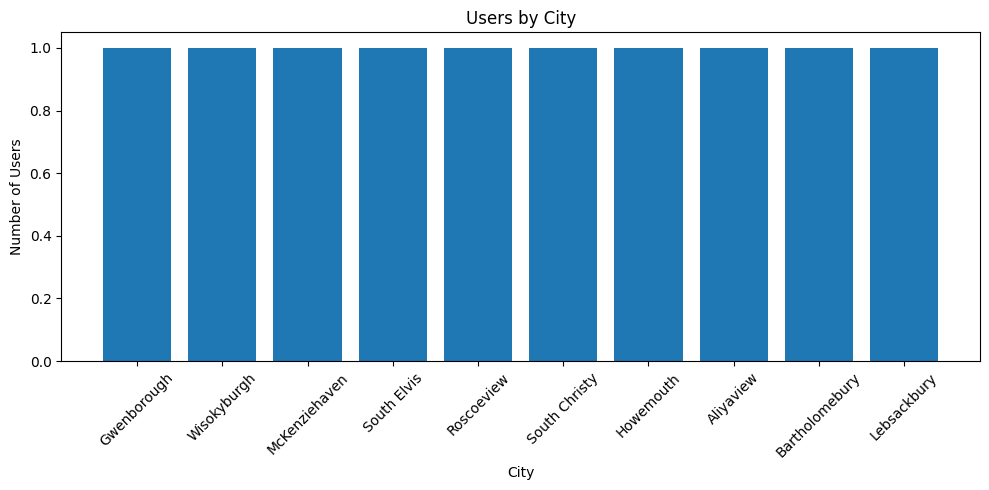

In [1]:

import requests
import matplotlib.pyplot as plt
import pandas as pd

# --------------------------------------------
# STEP 1: Fetch Data from Public API
# --------------------------------------------

# Public API URL (JSONPlaceholder API)
url = "https://jsonplaceholder.typicode.com/users"

# Send GET request
response = requests.get(url)

# Convert response to JSON
data = response.json()

# --------------------------------------------
# STEP 2: Convert Data into DataFrame
# --------------------------------------------

df = pd.DataFrame(data)

# Display first few rows
print("User Data:\n")
print(df[['id', 'name', 'email']])

# --------------------------------------------
# STEP 3: Create Visualization
# --------------------------------------------

# Count users by city
cities = [user['address']['city'] for user in data]

city_count = pd.Series(cities).value_counts()

# Plot Bar Chart
plt.figure(figsize=(10, 5))
plt.bar(city_count.index, city_count.values)

# Labels and Title
plt.xlabel("City")
plt.ylabel("Number of Users")
plt.title("Users by City")

# Rotate city names
plt.xticks(rotation=45)

# Show graph
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# TASK 2: AUTOMATED REPORT GENERATION
# ============================================

# Install required libraries (Run once if needed)
!pip install pandas matplotlib reportlab

import pandas as pd
import matplotlib.pyplot as plt
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.platypus.tables import Table
from reportlab.platypus.tables import TableStyle
from reportlab.lib import colors

# --------------------------------------------
# STEP 1: Read Data from CSV File
# --------------------------------------------

# Sample data
data = {
    "Student": ["Arita", "Roki", "Sam", "John", "David"],
    "Marks": [85, 90, 78, 88, 76]
}

# Convert into DataFrame
df = pd.DataFrame(data)

# Save CSV file
df.to_csv("students.csv", index=False)

print("CSV File Created Successfully!\n")
print(df)

# --------------------------------------------
# STEP 2: Analyze Data
# --------------------------------------------

average_marks = df["Marks"].mean()
highest_marks = df["Marks"].max()
lowest_marks = df["Marks"].min()

print("\nAnalysis Completed!")

# --------------------------------------------
# STEP 3: Create Visualization
# --------------------------------------------

plt.figure(figsize=(6,4))
plt.bar(df["Student"], df["Marks"])

plt.title("Student Marks Analysis")
plt.xlabel("Students")
plt.ylabel("Marks")

# Save chart image
plt.savefig("marks_chart.png")
plt.close()

print("Chart Created Successfully!")

# --------------------------------------------
# STEP 4: Generate PDF Report
# --------------------------------------------

# Create PDF
pdf = SimpleDocTemplate("Student_Report.pdf")

styles = getSampleStyleSheet()
elements = []

# Title
title = Paragraph("Automated Student Report", styles['Title'])
elements.append(title)

elements.append(Spacer(1, 12))

# Analysis text
analysis = f"""
Average Marks: {average_marks}<br/>
Highest Marks: {highest_marks}<br/>
Lowest Marks: {lowest_marks}
"""

elements.append(Paragraph(analysis, styles['BodyText']))

elements.append(Spacer(1, 12))

# Add Table
table_data = [df.columns.tolist()] + df.values.tolist()

table = Table(table_data)

table.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.grey),
    ('TEXTCOLOR', (0,0), (-1,0), colors.whitesmoke),
    ('GRID', (0,0), (-1,-1), 1, colors.black),
    ('FONTNAME', (0,0), (-1,0), 'Helvetica-Bold'),
    ('BACKGROUND', (0,1), (-1,-1), colors.beige),
]))

elements.append(table)

elements.append(Spacer(1, 20))

# Add Chart Image
elements.append(Image("marks_chart.png", width=400, height=200))

# Build PDF
pdf.build(elements)

print("\nPDF Report Generated Successfully!")
print("File Name: Student_Report.pdf")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 17.6 MB/s eta 0:00:00


In [ ]:
# ============================================
# TASK 3 : AI CHATBOT WITH NLP
# ============================================

# Install required libraries (Run once if needed)
# pip install nltk

import nltk
from nltk.chat.util import Chat, reflections

# Download NLTK data
nltk.download('punkt')

# --------------------------------------------
# STEP 1: Define Chatbot Responses
# --------------------------------------------

pairs = [

    # Greetings
    [
        r"hi|hello|hey",
        ["Hello! How can I help you today?",
         "Hi there! Ask me anything."]
    ],

    # Asking name
    [
        r"what is your name ?",
        ["I am an AI Chatbot created using Python and NLTK."]
    ],

    # Asking about Python
    [
        r"what is python ?",
        ["Python is a popular programming language used for AI, web development, data science, and more."]
    ],

    # Asking about NLP
    [
        r"what is nlp ?",
        ["NLP stands for Natural Language Processing. It helps computers understand human language."]
    ],

    # Asking about AI
    [
        r"what is ai ?",
        ["AI means Artificial Intelligence. It allows machines to think and learn like humans."]
    ],

    # Asking time
    [
        r"what time is it ?",
        ["Sorry, I cannot tell the current time right now."]
    ],

    # Help
    [
        r"help",
        ["You can ask me questions about Python, AI, NLP, or general greetings."]
    ],

    # Goodbye
    [
        r"bye|goodbye",
        ["Goodbye! Have a nice day.",
         "Bye! See you again."]
    ],

    # Default response
    [
        r"(.*)",
        ["Sorry, I don't understand that.",
         "Please ask another question."]
    ]
]

# --------------------------------------------
# STEP 2: Create Chatbot
# --------------------------------------------

chatbot = Chat(pairs, reflections)

# --------------------------------------------
# STEP 3: Start Chatbot
# --------------------------------------------

print("===================================")
print("      AI CHATBOT WITH NLP")
print("===================================")
print("Type 'bye' to exit.\n")

while True:

    user_input = input("You: ").lower()

    if user_input == "bye":
        print("Bot: Goodbye!")
        break

    response = chatbot.respond(user_input)

    print("Bot:", response)

In [ ]:
# ============================================
# TASK 4 : MACHINE LEARNING MODEL IMPLEMENTATION
# ============================================

# Install required libraries (Run once if needed)
# pip install pandas scikit-learn matplotlib

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# --------------------------------------------
# STEP 1: Create Dataset
# --------------------------------------------

data = {
    "Message": [
        "Congratulations! You won a free lottery ticket",
        "Claim your free prize now",
        "Hello friend how are you",
        "Let's meet tomorrow",
        "Win money instantly",
        "Important meeting at 5 PM",
        "Get free recharge today",
        "Project submission deadline tomorrow",
        "Earn cash quickly",
        "Happy birthday have a great day"
    ],

    "Label": [
        "Spam",
        "Spam",
        "Ham",
        "Ham",
        "Spam",
        "Ham",
        "Spam",
        "Ham",
        "Spam",
        "Ham"
    ]
}

# Convert into DataFrame
df = pd.DataFrame(data)

print("Dataset:\n")
print(df)

# --------------------------------------------
# STEP 2: Split Dataset
# --------------------------------------------

X = df["Message"]
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

# --------------------------------------------
# STEP 3: Convert Text into Numbers
# --------------------------------------------

vectorizer = CountVectorizer()

X_train_vectors = vectorizer.fit_transform(X_train)
X_test_vectors = vectorizer.transform(X_test)

# --------------------------------------------
# STEP 4: Train Machine Learning Model
# --------------------------------------------

model = MultinomialNB()

model.fit(X_train_vectors, y_train)

print("\nModel Training Completed!")

# --------------------------------------------
# STEP 5: Make Predictions
# --------------------------------------------

predictions = model.predict(X_test_vectors)

print("\nPredictions:")
print(predictions)

# --------------------------------------------
# STEP 6: Evaluate Model
# --------------------------------------------

accuracy = accuracy_score(y_test, predictions)

print("\nModel Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, predictions))

# --------------------------------------------
# STEP 7: Visualization
# --------------------------------------------

labels = ["Accuracy"]
scores = [accuracy * 100]

plt.figure(figsize=(5,4))
plt.bar(labels, scores)

plt.ylabel("Percentage")
plt.title("Model Accuracy")

# Show value on graph
for i, v in enumerate(scores):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center')

plt.show()

# --------------------------------------------
# STEP 8: Test with Custom Message
# --------------------------------------------

custom_message = ["Congratulations! You won cash prize"]

custom_vector = vectorizer.transform(custom_message)

result = model.predict(custom_vector)

print("\nCustom Message Prediction:")
print(custom_message[0], " --> ", result[0])